In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取昨天存好的预测结果
results_df = pd.read_csv('final_performance_results.csv')
# 确保日期格式正确
results_df['date'] = pd.to_datetime(results_df['date'])

#### 专业回测引擎

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. 设置交易参数 (核心：模拟真实摩擦) ---
FEES = 0.001  # 手续费 + 印花税 (单边千一)
SLIPPAGE = 0.0005  # 滑点 (万五)[价格在下单那一秒变化，想买的价格与实际成交价格之间的差额]
COST = FEES + SLIPPAGE#调仓一次的总成本

# --- 2. 策略逻辑构建 ---
# 假设预测值 pred > 0 时买入/持有，pred <= 0 时空仓
results_df['signal'] = np.where(results_df['pred'] > 0, 1, 0)

# 计算仓位变化（用于计算手续费）
# position_diff != 0 说明发生了调仓
results_df['pos_diff'] = results_df['signal'].diff().abs()
results_df.loc[results_df.index[0], 'pos_diff'] = 0 # 初始建仓暂不计，或设为1

# --- 3. 计算收益率 ---
# 市场基础收益率 (actual)
# 策略收益 = 信号 * 收益 - 调仓成本
results_df['strat_ret_raw'] = results_df['signal'].shift(1) * results_df['actual']
results_df['trade_cost'] = results_df['pos_diff'] * COST
results_df['strat_ret_net'] = results_df['strat_ret_raw'] - results_df['trade_cost']

# --- 4. 计算累计净值 ---
results_df['cum_market'] = (1 + results_df['actual']).cumprod()
results_df['cum_strategy'] = (1 + results_df['strat_ret_net'].fillna(0)).cumprod()

# --- 5. 计算量化核心指标 ---
total_ret = results_df['cum_strategy'].iloc[-1] - 1
annual_ret = (total_ret + 1) ** (252 / len(results_df)) - 1
sharpe = results_df['strat_ret_net'].mean() / (results_df['strat_ret_net'].std() + 1e-9) * np.sqrt(252)
max_drawdown = (1 - results_df['cum_strategy'] / results_df['cum_strategy'].cummax()).max()

print(f" 策略净值计算完毕！")
print(f" 累计净值: {results_df['cum_strategy'].iloc[-1]:.4f}")
print(f" 年化收益: {annual_ret:.2%}")
print(f" 夏普比率 (Sharpe): {sharpe:.2f}")#夏普比率：每承担一份风险，能换回多少超额收益。
print(f" 最大回撤: {max_drawdown:.2%}")#最大回撤：你的策略从最高点跌下来最惨的一次跌了多少。

 策略净值计算完毕！
 累计净值: 1.0044
 年化收益: 0.41%
 夏普比率 (Sharpe): 0.17
 最大回撤: 2.93%


###### 夏普比率 (0.17)：
######   诊断：较低。通常职业量化实盘要求夏普比率在 1.0 以上，优秀策略在 2.0 以上。
######   含义：你的策略虽然在赚钱，但赚得“太辛苦”了。波动和风险相对于收益来说偏大。

#### 可视化回测图谱

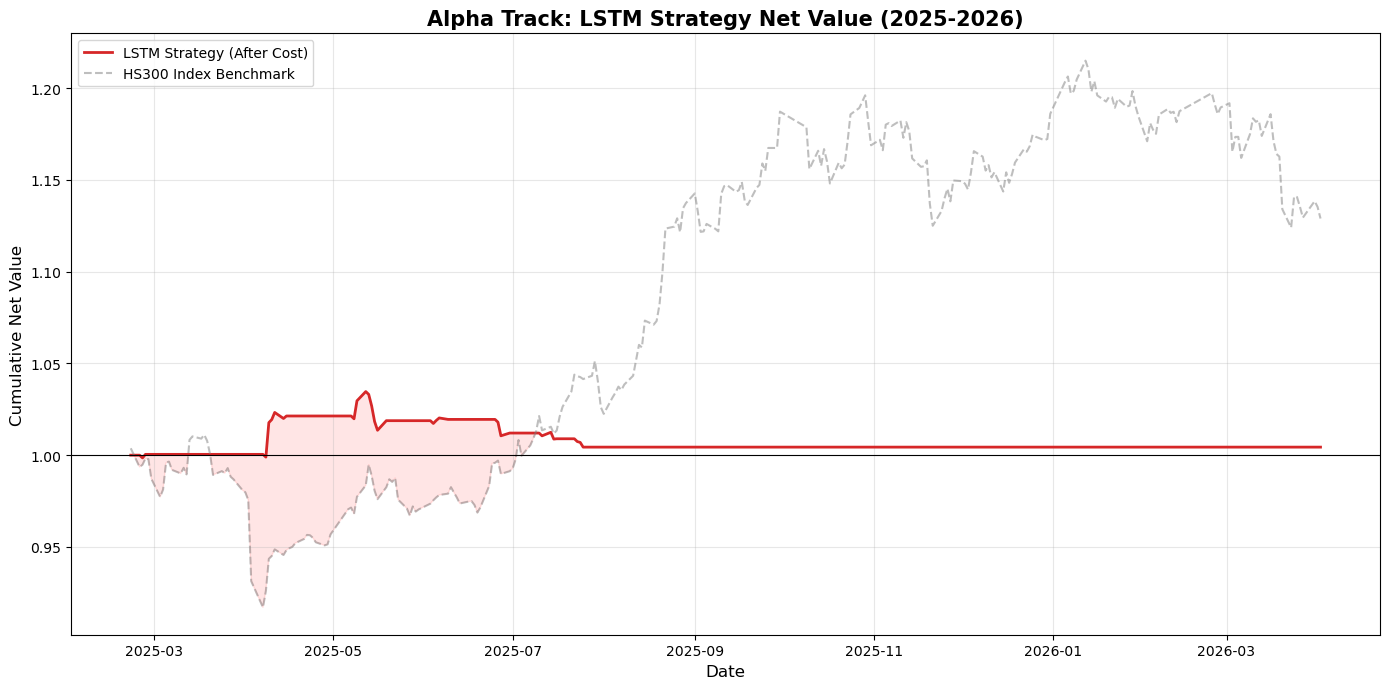

In [5]:
import matplotlib.pyplot as plt

# --- 1. 显式转换为 Numpy 数组，彻底规避 ValueError ---
plot_dates = results_df['date'].values
cum_strategy = results_df['cum_strategy'].values
cum_market = results_df['cum_market'].values

# --- 2. 开始绘图 ---
plt.figure(figsize=(14, 7), dpi=100)

# 绘制策略净值（红色）
plt.plot(plot_dates, cum_strategy, label='LSTM Strategy (After Cost)', color='#d62728', linewidth=2)

# 绘制基准净值（灰色）
plt.plot(plot_dates, cum_market, label='HS300 Index Benchmark', color='#7f7f7f', alpha=0.5, linestyle='--')

# --- 3. 涂色：直观展示超额收益 (Alpha) ---
# 当策略跑赢基准时，填充浅红色
plt.fill_between(plot_dates, cum_strategy, cum_market, 
                 where=(cum_strategy >= cum_market), 
                 color='red', alpha=0.1, interpolate=True)

# --- 4. 修饰图表 ---
plt.title('Alpha Track: LSTM Strategy Net Value (2025-2026)', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Net Value', fontsize=12)
plt.axhline(1.0, color='black', linewidth=0.8, linestyle='-') # 初始资金线
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# 自动调整布局，防止标签重叠
plt.tight_layout()
plt.show()

In [6]:
# 计算回撤
results_df['cummax'] = results_df['cum_strategy'].cummax()
results_df['drawdown'] = (results_df['cum_strategy'] - results_df['cummax']) / results_df['cummax']

# 在图中下方增加一个小图显示回撤（可选，或者直接在标题写出）
print(f"最大回撤: {results_df['drawdown'].min():.2%}")

最大回撤: -2.93%


📉 策略最大回撤: 2.93%


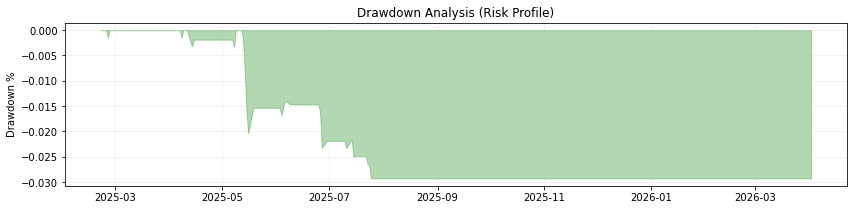

In [7]:
# 计算最大回撤（取绝对值）
max_dd = abs(results_df['drawdown'].min())
print(f" 策略最大回撤: {max_dd:.2%}")

# 画出回撤面积图
plt.figure(figsize=(14, 3))
plt.fill_between(results_df['date'], results_df['drawdown'], 0, color='green', alpha=0.3)
plt.title('Drawdown Analysis (Risk Profile)', fontsize=12)
plt.ylabel('Drawdown %')
plt.grid(True, alpha=0.2)
plt.show()